# Part 3: Gaze Estimation

Estimate gaze direction using [L2CS-Net](https://github.com/Ahmednull/L2CS-Net), then train linear and nonlinear regression models on landmark features to predict gaze direction.

In [ ]:
!pip install mediapipe
!wget -O face_landmarker_v2_with_blendshapes.task -q \
  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [ ]:
from google.colab import files

import cv2
from google.colab.patches import cv2_imshow
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np
import matplotlib.pyplot as plt
import math
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from PIL import Image, ImageDraw

In [ ]:
import glob
import re

img_list = glob.glob('./*.png')

def extract_number(item):
    match = re.search(r'\d+', item)
    return int(match.group()) if match else 0

sorted_list = sorted(img_list, key=extract_number)
sorted_list

['./face_1.png',
 './face_2.png',
 './face_3.png',
 './face_4.png',
 './face_5.png',
 './face_6.png',
 './face_7.png',
 './face_8.png',
 './face_9.png',
 './face_11.png',
 './face_12.png',
 './face_13.png',
 './face_14.png',
 './face_21.png',
 './face_22.png',
 './face_23.png',
 './face_24.png',
 './face_31.png',
 './face_32.png']

In [ ]:
base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    num_faces=1
)
detector = vision.FaceLandmarker.create_from_options(options)

In [ ]:
import os
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.backends.cudnn as cudnn
import torchvision

from l2cs import select_device, draw_gaze, getArch, Pipeline, render

In [ ]:
gaze_pipeline = Pipeline(
    weights='./L2CSNet_gaze360.pkl',
    arch='ResNet50',
    device=select_device('0', batch_size=1)
)

In [ ]:
def gaze_estimate(img_path):
    img = cv2.imread(img_path)
    result = gaze_pipeline.step(img)
    img = render(img, result)
    return img

### Gaze Estimation Results

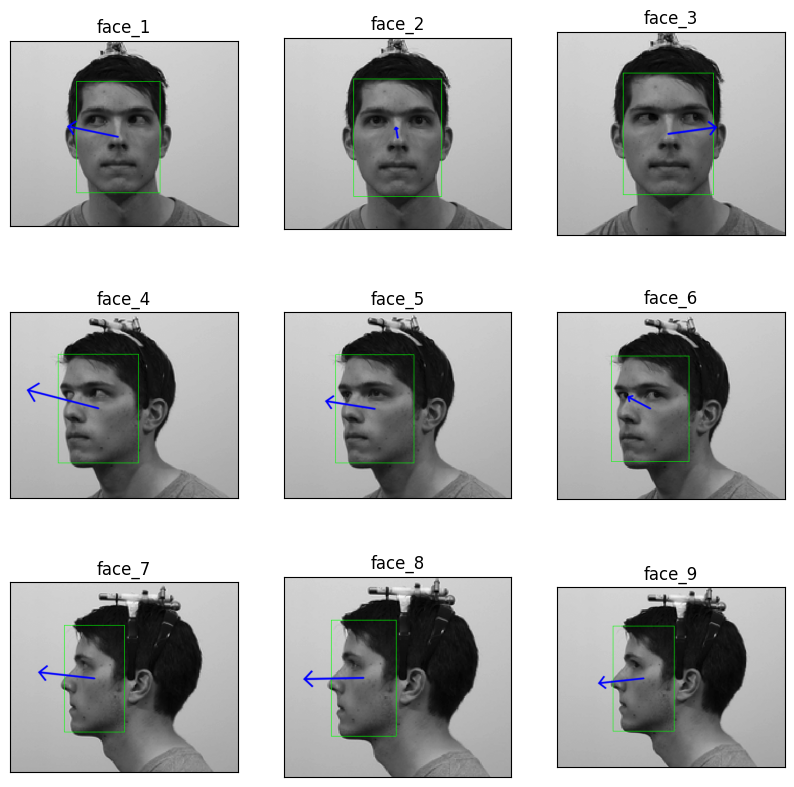

In [43]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        img = sorted_list[3*i+j]
        gaze = gaze_estimate(img)
        axes[i, j].imshow(gaze)
        axes[i, j].set_title(f"{img.split('/')[-1].split('.')[0]}")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.show()

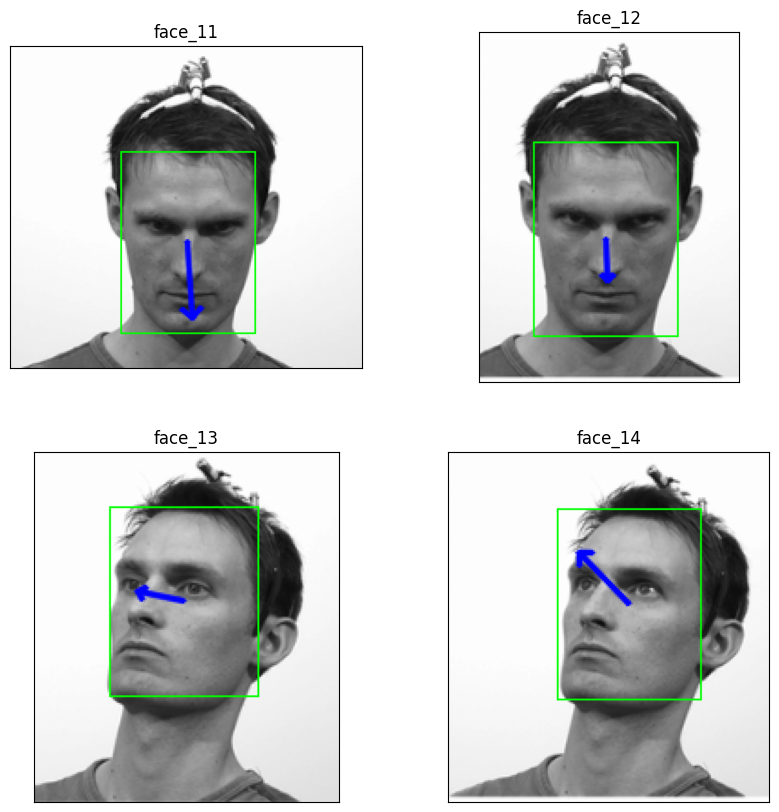

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    for j in range(2):
        img = sorted_list[9+2*i+j]
        gaze = gaze_estimate(img)
        axes[i, j].imshow(gaze)
        axes[i, j].set_title(f"{img.split('/')[-1].split('.')[0]}")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.show()

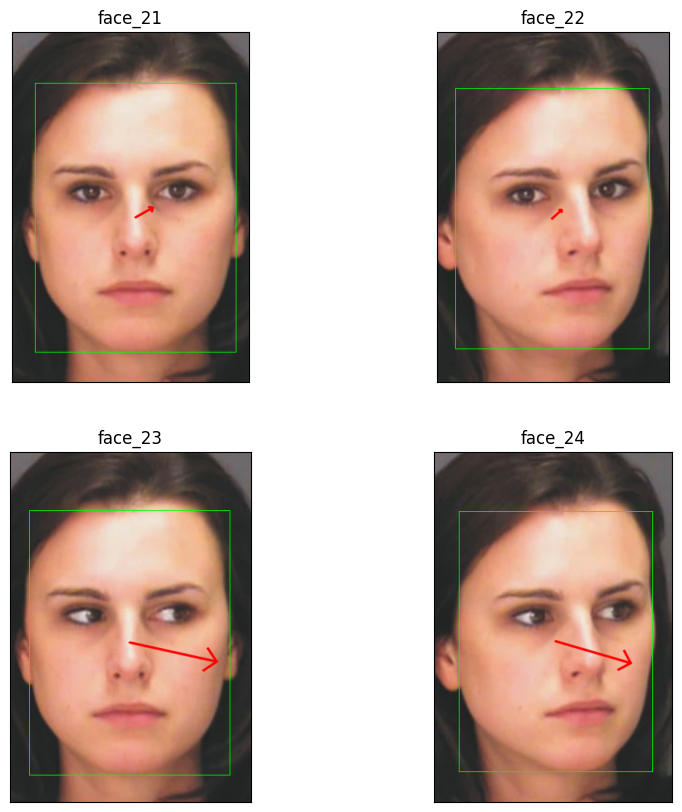

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    for j in range(2):
        img = sorted_list[13+2*i+j]
        gaze = gaze_estimate(img)
        axes[i, j].imshow(gaze[:, :, ::-1])
        axes[i, j].set_title(f"{img.split('/')[-1].split('.')[0]}")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.show()

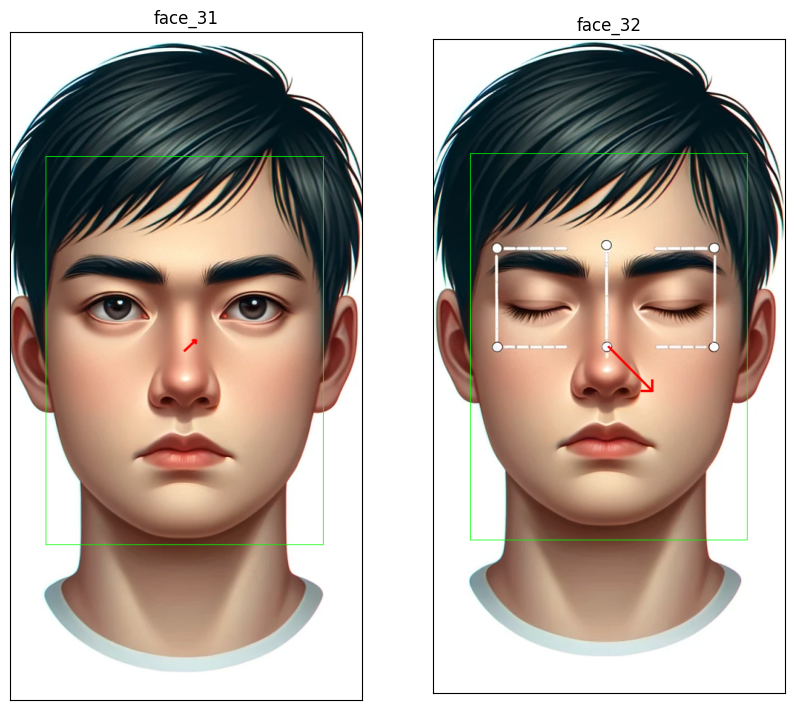

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10))
img = sorted_list[17]
gaze = gaze_estimate(img)
axes[0].imshow(gaze[:, :, ::-1])
axes[0].set_title(f"{img.split('/')[-1].split('.')[0]}")
axes[0].set_xticks([])
axes[0].set_yticks([])

img = sorted_list[18]
gaze = gaze_estimate(img)
axes[1].imshow(gaze[:, :, ::-1])
axes[1].set_title(f"{img.split('/')[-1].split('.')[0]}")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.show()

### 3.2 Gaze Direction Regression from Landmarks

**Input features:** iris center coordinates, eyebrow center coordinates, iris orientation angle

**Output:** 8-direction gaze classification (+ center = 9 classes)

We compare linear and nonlinear regression models. With only 19 training images, the dataset is limited, but the nonlinear model shows higher accuracy. Intuitively, the difference `iris_center[x] - eyebrow_center[x]` is a strong signal for left/right gaze, suggesting that a linear model would perform well with more data.

In [ ]:
def centers(image_path):
    """Extract iris and eyebrow center coordinates + orientation angles."""
    image = mp.Image.create_from_file(image_path)
    detection_result = detector.detect(image)
    (RIC_x, RIC_y, RBC_x, RBC_y, right_angle) = (0, 0, 0, 0, 0)
    (LIC_x, LIC_y, LBC_x, LBC_y, left_angle) = (0, 0, 0, 0, 0)

    if detection_result.face_blendshapes != []:
        rightEyeIris = detection_result.face_landmarks[0][473:]
        leftEyeIris = detection_result.face_landmarks[0][468:473]

        rightEyeIris_center = detection_result.face_landmarks[0][473]
        rightEyebrow_center = detection_result.face_landmarks[0][296]
        leftEyeIris_center = detection_result.face_landmarks[0][468]
        leftEyebrow_center = detection_result.face_landmarks[0][66]

        # Right eye iris center (mean of peripheral landmarks)
        sum_x = sum(lm.x for lm in rightEyeIris[1:])
        sum_y = sum(lm.y for lm in rightEyeIris[1:])
        approx_right_center = (sum_x / len(rightEyeIris[1:]), sum_y / len(rightEyeIris[1:]))

        # Left eye iris center
        sum_x = sum(lm.x for lm in leftEyeIris[1:])
        sum_y = sum(lm.y for lm in leftEyeIris[1:])
        approx_left_center = (sum_x / len(leftEyeIris[1:]), sum_y / len(leftEyeIris[1:]))

        # Right eye: major/minor axis and orientation
        right_axis = [abs(rightEyeIris[1].x - approx_right_center[0]),
                      abs(rightEyeIris[2].y - approx_right_center[1])]
        right_major_angle_candi = np.argmax(right_axis)

        # Left eye: major/minor axis and orientation
        left_axis = [abs(leftEyeIris[1].x - approx_left_center[0]),
                     abs(leftEyeIris[2].y - approx_left_center[1])]
        left_major_angle_candi = np.argmax(left_axis)

        if right_major_angle_candi == 0:
            right_angle = math.atan2(rightEyeIris[1].y - approx_right_center[1],
                                     rightEyeIris[1].x - approx_right_center[0])
        else:
            right_angle = math.atan2(rightEyeIris[2].y - approx_right_center[1],
                                     rightEyeIris[2].x - approx_right_center[0])

        if left_major_angle_candi == 0:
            left_angle = math.atan2(leftEyeIris[1].y - approx_left_center[1],
                                    leftEyeIris[1].x - approx_left_center[0])
        else:
            left_angle = math.atan2(leftEyeIris[2].y - approx_left_center[1],
                                    leftEyeIris[2].x - approx_left_center[0])

        RIC_x, RIC_y = rightEyeIris_center.x, rightEyeIris_center.y
        RBC_x, RBC_y = rightEyebrow_center.x, rightEyebrow_center.y
        LIC_x, LIC_y = leftEyeIris_center.x, leftEyeIris_center.y
        LBC_x, LBC_y = leftEyebrow_center.x, leftEyebrow_center.y

    return (RIC_x, RIC_y, RBC_x, RBC_y, right_angle), (LIC_x, LIC_y, LBC_x, LBC_y, left_angle)

### Model Definitions: Linear & Nonlinear Regression

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import DataLoader, TensorDataset


class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)


class NonlinearRegressionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NonlinearRegressionModel, self).__init__()
        self.hidden_layer = nn.Linear(input_dim, hidden_dim)
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.hidden_layer(x))
        x = self.output_layer(x)
        return x

In [ ]:
def train_model(model, dataloader, criterion, optimizer, num_epochs=50):
    model.train()
    train_losses = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(dataloader.dataset)
        train_losses.append(epoch_loss)
    print(f'Training finished, loss: {epoch_loss:.4f}')
    return train_losses


def evaluate_model(model, dataloader):
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            predictions.append(outputs.numpy())
            actuals.append(targets.numpy())
    return np.concatenate(predictions), np.concatenate(actuals)


def linear_regre(tensor_x, tensor_y):
    dataset = TensorDataset(tensor_x, tensor_y)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
    model = LinearRegressionModel(tensor_x.shape[1], tensor_y.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_model(model, dataloader, criterion, optimizer, num_epochs=100)
    return evaluate_model(model, dataloader)


def Nonlinear_regre(tensor_x, tensor_y, hidden_dim=10):
    dataset = TensorDataset(tensor_x, tensor_y)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
    model = NonlinearRegressionModel(tensor_x.shape[1], hidden_dim, tensor_y.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    train_model(model, dataloader, criterion, optimizer, num_epochs=100)
    return evaluate_model(model, dataloader)

In [ ]:
import random

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### Prepare Training Data

In [ ]:
feat_list = []
for i, l in enumerate(sorted_list):
    feat_list.append(centers(l)[0])
tensor_x = torch.tensor(feat_list, dtype=torch.float32)

In [ ]:
# Labels: 9 gaze directions (0=center, 1=up, 2=up-right, 3=right, 4=down-right, 5=down, 6=down-left, 7=left, 8=up-left)
labels = np.array([7, 0, 3, 8, 7, 3, 8, 7, 0, 5, 0, 7, 8, 0, 0, 3, 3, 0, 0])
onehot_encoder9 = OneHotEncoder(sparse=True, categories=[np.arange(9)])
labels = onehot_encoder9.fit_transform(labels.reshape(-1, 1))
tensor_y = torch.tensor(labels.toarray(), dtype=torch.float32)

### Linear Model Fitting

In [ ]:
y_pred, y_true = linear_regre(tensor_x, tensor_y)
for i, l in enumerate(y_pred):
    print(sorted_list[i].split('/')[-1], ' - true:', np.argmax(y_true[i]), 'pred:', np.argmax(l))

train finish, Loss: 0.0799
face_1.png  - true :  7 pred : 0
face_2.png  - true :  0 pred : 0
face_3.png  - true :  3 pred : 0
face_4.png  - true :  8 pred : 0
face_5.png  - true :  7 pred : 0
face_6.png  - true :  3 pred : 0
face_7.png  - true :  8 pred : 8
face_8.png  - true :  7 pred : 8
face_9.png  - true :  0 pred : 0
face_11.png  - true :  5 pred : 0
face_12.png  - true :  0 pred : 0
face_13.png  - true :  7 pred : 0
face_14.png  - true :  8 pred : 0
face_21.png  - true :  0 pred : 0
face_22.png  - true :  0 pred : 0
face_23.png  - true :  3 pred : 0
face_24.png  - true :  3 pred : 0
face_31.png  - true :  0 pred : 0
face_32.png  - true :  0 pred : 0


### Nonlinear Model Fitting

In [ ]:
y_pred, y_true = Nonlinear_regre(tensor_x, tensor_y)
for i, l in enumerate(y_pred):
    print(sorted_list[i].split('/')[-1], ' - true:', np.argmax(y_true[i]), 'pred:', np.argmax(l))

train finish, Loss: 0.0667
face_1.png  - true :  7 pred : 0
face_2.png  - true :  0 pred : 0
face_3.png  - true :  3 pred : 0
face_4.png  - true :  8 pred : 7
face_5.png  - true :  7 pred : 7
face_6.png  - true :  3 pred : 7
face_7.png  - true :  8 pred : 7
face_8.png  - true :  7 pred : 7
face_9.png  - true :  0 pred : 7
face_11.png  - true :  5 pred : 0
face_12.png  - true :  0 pred : 0
face_13.png  - true :  7 pred : 7
face_14.png  - true :  8 pred : 8
face_21.png  - true :  0 pred : 0
face_22.png  - true :  0 pred : 0
face_23.png  - true :  3 pred : 0
face_24.png  - true :  3 pred : 0
face_31.png  - true :  0 pred : 0
face_32.png  - true :  0 pred : 0


### Visualization: Predicted vs. Actual Gaze Direction

In [ ]:
def draw_pupil_arrow(image_path, r_center_x, r_center_y, l_center_x, l_center_y,
                      direction_real, direction_pred):
    image = cv2.imread(image_path)
    plt.imshow(image[..., ::-1])
    x_shape = image.shape[1]
    y_shape = image.shape[0]
    r_center_x *= x_shape
    r_center_y *= y_shape
    l_center_x *= x_shape
    l_center_y *= y_shape

    plt.scatter([r_center_x, l_center_x], [r_center_y, l_center_y], color='red')

    # Direction vectors: 0=center, 1=up, 2=up-right, 3=right, ..., 8=up-left
    direction_vectors = [
        (0, 0), (0, -1), (1, -1), (1, 0), (1, 1),
        (0, 1), (-1, 1), (-1, 0), (-1, -1)
    ]

    dx, dy = direction_vectors[direction_pred]
    plt.arrow(r_center_x, r_center_y, dx * 20, dy * 20,
              head_width=5, head_length=10, fc='blue', ec='blue')
    dx, dy = direction_vectors[direction_real]
    plt.arrow(r_center_x, r_center_y, dx * 20, dy * 20,
              head_width=5, head_length=10, fc='red', ec='red')
    plt.axis('off')
    plt.title('Red=ground truth, Blue=predicted')
    plt.show()

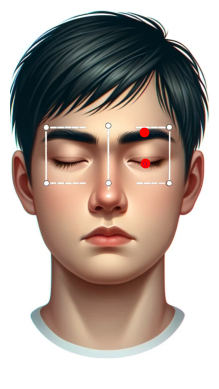

In [150]:
num = 18
draw_pupil_arrow(sorted_list[num],
                 feat_list[num][0], feat_list[num][1],
                 feat_list[num][2], feat_list[num][3],
                 np.argmax(y_true[num]), np.argmax(y_pred[num]))

### Future Work

Adding head pose estimation (yaw, pitch, roll) as additional input features to the regression model could further improve gaze prediction accuracy.

In [ ]:
# Head pose estimation via PnP (example code)
size = image.numpy_view().shape
focal_length = size[1]
center = (size[1] / 2, size[0] / 2)
camera_matrix = np.array([
    [focal_length, 0, center[0]],
    [0, focal_length, center[1]],
    [0, 0, 1]
], dtype='double')

# model_points = <3D landmark coordinates>
# image_points = <2D landmark coordinates>
dist_coeffs = np.zeros((4, 1))

# (success, rotation_vector, translation_vector) = cv2.solvePnP(
#     model_points, image_points, camera_matrix, dist_coeffs)
# rotation_matrix, _ = cv2.Rodrigues(rotation_vector)
#
# # Extract Euler angles from rotation matrix
# sy = np.sqrt(rotation_matrix[0, 0]**2 + rotation_matrix[1, 0]**2)
# singular = sy < 1e-6
# if not singular:
#     yaw = np.arctan2(rotation_matrix[2, 1], rotation_matrix[2, 2])
#     pitch = np.arctan2(-rotation_matrix[2, 0], sy)
#     roll = np.arctan2(rotation_matrix[1, 0], rotation_matrix[0, 0])
# else:
#     yaw = np.arctan2(-rotation_matrix[1, 2], rotation_matrix[1, 1])
#     pitch = np.arctan2(-rotation_matrix[2, 0], sy)
#     roll = 0
#
# yaw, pitch, roll = np.degrees(yaw), np.degrees(pitch), np.degrees(roll)